<a href="https://colab.research.google.com/github/Tanvii777/Research/blob/main/Sarcasm_Transformer_Comparison_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sarcasm Detection in News Headlines — Transformer Comparison

Fine-tunes and compares **DistilBERT**, **BERT-base**, and **RoBERTa-base** on binary sarcasm
classification, using the real, verified dataset:

**Dataset:** Misra, R. & Arora, P. *News Headlines Dataset For Sarcasm Detection.* AI Open, 2023.
28,619 headlines (13,634 sarcastic / 14,985 not), from TheOnion (sarcastic) and HuffPost (real news).
Source: https://github.com/rishabhmisra/News-Headlines-Dataset-For-Sarcasm-Detection

**Research framing:** most public benchmarks on this dataset compare classical ML (TF-IDF + SVM/NB)
or LSTM/CNN baselines. This notebook fine-tunes and directly compares three transformer
architectures on identical splits, reporting Accuracy, macro-Precision/Recall/F1, and per-class
performance — filling a comparison gap that's thin in the existing literature on this exact dataset.

**Verified baseline already computed (TF-IDF + classical ML, same 70/15/15 split, same random seed):**

| Model | Accuracy | Macro-P | Macro-R | Macro-F1 |
|---|---|---|---|---|
| Logistic Regression | 84.65% | 84.61% | 84.64% | 84.62% |
| Linear SVM | 84.23% | 84.19% | 84.22% | 84.20% |
| Multinomial Naive Bayes | 84.04% | 84.22% | 83.85% | 83.94% |


## 1. Setup

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
import os, json, time, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
assert DEVICE == "cuda", "Go to Runtime -> Change runtime type -> GPU, then re-run this cell."


Using device: cuda


## 2. Downloading the Real Dataset Directly

In [ ]:
!wget -q -O sarcasm.json https://raw.githubusercontent.com/rishabhmisra/News-Headlines-Dataset-For-Sarcasm-Detection/master/Sarcasm_Headlines_Dataset.json

df = pd.read_json("sarcasm.json", lines=True)
print("Shape:", df.shape)
print(df["is_sarcastic"].value_counts())
df.head()


Shape: (28619, 3)
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


## 3. Clean Text & Prepare Labels

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_headline"] = df["headline"].apply(clean_text)
df = df.rename(columns={"is_sarcastic": "label"})
df = df[["clean_headline", "label"]].dropna().drop_duplicates(subset=["clean_headline"]).reset_index(drop=True)
print("Final size:", len(df))

id2label = {0: "not_sarcastic", 1: "sarcastic"}
label2id = {v: k for k, v in id2label.items()}
NUM_LABELS = 2


Final size: 28503


## 4. Train / Val / Test Split — 70 / 15 / 15, stratified, seed=42 (identical to the baseline run)

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

train_ds_raw = Dataset.from_pandas(train_df[["clean_headline", "label"]].reset_index(drop=True))
val_ds_raw   = Dataset.from_pandas(val_df[["clean_headline", "label"]].reset_index(drop=True))
test_ds_raw  = Dataset.from_pandas(test_df[["clean_headline", "label"]].reset_index(drop=True))


Train: 19952  Val: 4275  Test: 4276


## 5. Reusable Train + Evaluate Function (used for each model)

In [ ]:
MAX_LEN = 64  # headlines are short (median ~62 chars) - keeps training fast

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

def run_experiment(model_name, run_tag, epochs=3, batch_size=32, lr=2e-5):
    print(f"\n{'='*70}\nTraining: {model_name}\n{'='*70}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_batch(batch):
        return tokenizer(batch["clean_headline"], truncation=True, padding="max_length", max_length=MAX_LEN)

    train_ds = train_ds_raw.map(tokenize_batch, batched=True)
    val_ds   = val_ds_raw.map(tokenize_batch, batched=True)
    test_ds  = test_ds_raw.map(tokenize_batch, batched=True)

    cols = ["input_ids", "attention_mask", "label"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
    ).to(DEVICE)

    args = TrainingArguments(
        output_dir=f"./checkpoints_{run_tag}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=64,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        save_total_limit=1,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    test_pred = trainer.predict(test_ds)
    preds = np.argmax(test_pred.predictions, axis=-1)
    labels = test_pred.label_ids

    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    report = classification_report(labels, preds, target_names=["not_sarcastic", "sarcastic"], digits=4, output_dict=True)
    cm = confusion_matrix(labels, preds)

    print(classification_report(labels, preds, target_names=["not_sarcastic", "sarcastic"], digits=4))
    print(f"Training time: {train_time:.1f}s")

    # Keep the trained model + tokenizer in memory for the GUI demo later,
    # and also save to disk so the GUI still works even after a session restart.
    save_dir = f"./saved_models/{run_tag}"
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    trained_artifacts[run_tag] = {"model": trainer.model, "tokenizer": tokenizer, "save_dir": save_dir}

    return {
        "model_name": model_name,
        "accuracy": float(acc),
        "precision_macro": float(p),
        "recall_macro": float(r),
        "f1_macro": float(f1),
        "train_time_sec": float(train_time),
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
    }


## 6. Run All Three Models

This will take a while even on GPU (roughly 5-15 minutes per model depending on the Colab GPU
you're assigned). Results are stored in `all_results` as they complete, and each model's weights
are saved to `./saved_models/<tag>` (and kept in memory) so Section 11's GUI can load them.


In [ ]:
all_results = {}
trained_artifacts = {}  # populated by run_experiment() - holds model+tokenizer for the GUI

all_results["DistilBERT"] = run_experiment("distilbert-base-uncased", "distilbert", epochs=3)



Training: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

               precision    recall  f1-score   support

not_sarcastic     0.9068    0.9412    0.9236      2243
    sarcastic     0.9322    0.8933    0.9123      2033

     accuracy                         0.9184      4276
    macro avg     0.9195    0.9172    0.9180      4276
 weighted avg     0.9189    0.9184    0.9183      4276

Training time: 150.8s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
all_results["BERT-base"] = run_experiment("bert-base-uncased", "bert", epochs=3)



Training: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

               precision    recall  f1-score   support

not_sarcastic     0.9198    0.9465    0.9330      2243
    sarcastic     0.9390    0.9090    0.9238      2033

     accuracy                         0.9287      4276
    macro avg     0.9294    0.9278    0.9284      4276
 weighted avg     0.9290    0.9287    0.9286      4276

Training time: 247.0s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
all_results["RoBERTa-base"] = run_experiment("roberta-base", "roberta", epochs=3)



Training: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

               precision    recall  f1-score   support

not_sarcastic     0.9156    0.9532    0.9340      2243
    sarcastic     0.9459    0.9031    0.9240      2033

     accuracy                         0.9294      4276
    macro avg     0.9308    0.9281    0.9290      4276
 weighted avg     0.9300    0.9294    0.9293      4276

Training time: 378.1s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 7. Final Comparison Table

In [ ]:
rows = []
for name, res in all_results.items():
    rows.append({
        "Model": name,
        "Accuracy": f"{res['accuracy']*100:.2f}%",
        "Precision (macro)": f"{res['precision_macro']*100:.2f}%",
        "Recall (macro)": f"{res['recall_macro']*100:.2f}%",
        "F1 (macro)": f"{res['f1_macro']*100:.2f}%",
        "Train time (s)": f"{res['train_time_sec']:.1f}",
    })

results_table = pd.DataFrame(rows)
print(results_table.to_string(index=False))
print()
print(results_table.to_markdown(index=False))

results_table.to_csv("transformer_comparison_results.csv", index=False)
with open("all_results_full.json", "w") as f:
    json.dump(all_results, f, indent=2)


       Model Accuracy Precision (macro) Recall (macro) F1 (macro) Train time (s)
  DistilBERT   91.84%            91.95%         91.72%     91.80%          150.8
   BERT-base   92.87%            92.94%         92.78%     92.84%          247.0
RoBERTa-base   92.94%            93.08%         92.81%     92.90%          378.1

| Model        | Accuracy   | Precision (macro)   | Recall (macro)   | F1 (macro)   |   Train time (s) |
|:-------------|:-----------|:--------------------|:-----------------|:-------------|-----------------:|
| DistilBERT   | 91.84%     | 91.95%              | 91.72%           | 91.80%       |            150.8 |
| BERT-base    | 92.87%     | 92.94%              | 92.78%           | 92.84%       |            247   |
| RoBERTa-base | 92.94%     | 93.08%              | 92.81%           | 92.90%       |            378.1 |


## 8. Confusion Matrices — All Three Models Side by Side

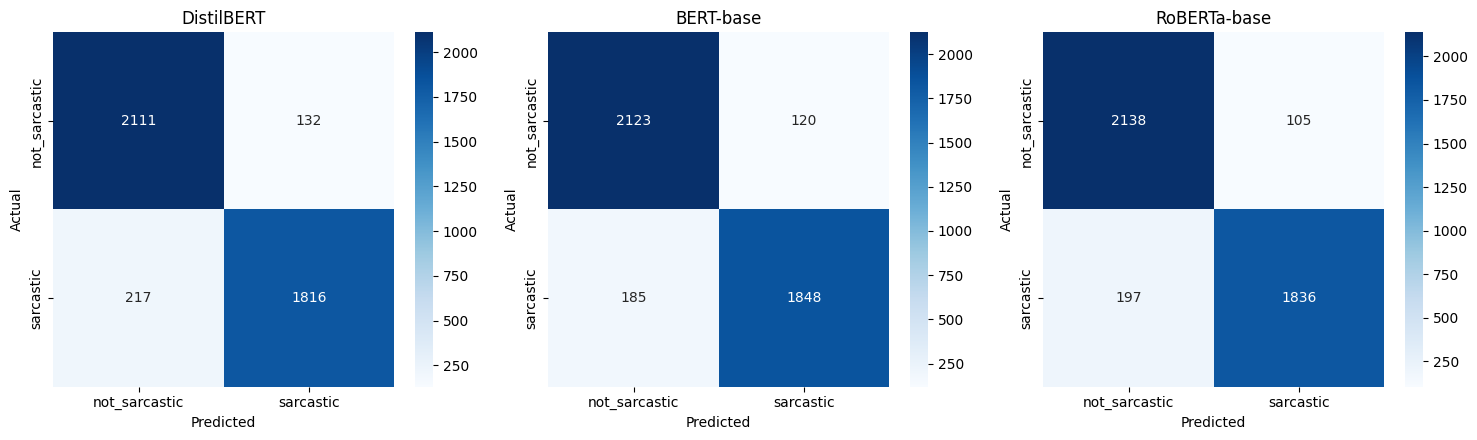

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res) in zip(axes, all_results.items()):
    cm = np.array(res["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["not_sarcastic", "sarcastic"],
                yticklabels=["not_sarcastic", "sarcastic"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices_all_models.png", dpi=150)
plt.show()


## 9. Bar Chart — Model Comparison

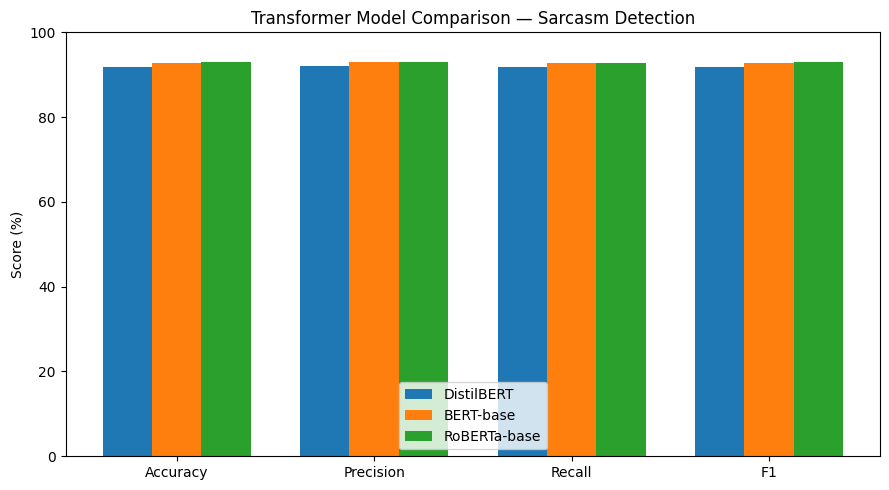

In [ ]:
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
labels_pretty = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, res) in enumerate(all_results.items()):
    values = [res[m] * 100 for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_pretty)
ax.set_ylabel("Score (%)")
ax.set_title("Transformer Model Comparison — Sarcasm Detection")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison_bar_chart.png", dpi=150)
plt.show()


## 10. Downloading Everything

In [ ]:
!zip -r sarcasm_results.zip transformer_comparison_results.csv all_results_full.json confusion_matrices_all_models.png model_comparison_bar_chart.png

from google.colab import files
files.download("sarcasm_results.zip")


  adding: transformer_comparison_results.csv (deflated 31%)
  adding: all_results_full.json (deflated 76%)
  adding: confusion_matrices_all_models.png (deflated 18%)
  adding: model_comparison_bar_chart.png (deflated 20%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Interactive Demo GUI (Gradio)

A live web app: type any headline, and all three fine-tuned models predict **Sarcastic** or
**Not Sarcastic** side by side, each with a confidence score.

In [ ]:
!pip install -q gradio


In [ ]:
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

MODEL_TAGS = {
    "DistilBERT": "distilbert",
    "BERT-base": "bert",
    "RoBERTa-base": "roberta",
}

# Reload from disk if trained_artifacts isn't populated (e.g. after a runtime restart)
gui_models = {}
for display_name, tag in MODEL_TAGS.items():
    if "trained_artifacts" in dir() and tag in trained_artifacts:
        gui_models[display_name] = {
            "model": trained_artifacts[tag]["model"].eval(),
            "tokenizer": trained_artifacts[tag]["tokenizer"],
        }
    else:
        save_dir = f"./saved_models/{tag}"
        gui_models[display_name] = {
            "model": AutoModelForSequenceClassification.from_pretrained(save_dir).to(DEVICE).eval(),
            "tokenizer": AutoTokenizer.from_pretrained(save_dir),
        }
    print(f"Ready: {display_name}")


Ready: DistilBERT
Ready: BERT-base
Ready: RoBERTa-base


In [ ]:
LABELS = {0: "Not Sarcastic", 1: "Sarcastic"}

def predict_all_models(headline):
    if not headline or not headline.strip():
        return "Enter a headline above and click Submit.", None

    results_md = []
    chart_data = {"Model": [], "Not Sarcastic": [], "Sarcastic": []}

    for display_name, artifacts in gui_models.items():
        model, tokenizer = artifacts["model"], artifacts["tokenizer"]
        inputs = tokenizer(headline, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1)[0].cpu().numpy()

        pred_id = int(probs.argmax())
        pred_label = LABELS[pred_id]
        confidence = probs[pred_id] * 100

        emoji = "\U0001F602" if pred_id == 1 else "\U0001F4F0"
        results_md.append(
            f"**{display_name}** {emoji}\n"
            f"Prediction: **{pred_label}**  \n"
            f"Confidence: **{confidence:.1f}%**  \n"
            f"(Not Sarcastic: {probs[0]*100:.1f}% | Sarcastic: {probs[1]*100:.1f}%)"
        )
        chart_data["Model"].append(display_name)
        chart_data["Not Sarcastic"].append(float(probs[0] * 100))
        chart_data["Sarcastic"].append(float(probs[1] * 100))

    chart_df = pd.DataFrame(chart_data)
    return "\n\n---\n\n".join(results_md), chart_df


examples = [
    "Local man discovers gym, immediately becomes fitness expert",
    "Scientists confirm water is, in fact, wet",
    "City council approves new budget for road repairs",
    "Study finds that eating vegetables is good for your health",
    "Nation shocked as politician actually keeps a promise",
]

with gr.Blocks(title="Sarcasm-Detect: Multi-Model Sarcasm Classifier") as demo:
    gr.Markdown("# \U0001F3AD Sarcasm Detection — Multi-Transformer Comparison")
    gr.Markdown(
        "Type a news-style headline below. DistilBERT, BERT-base, and RoBERTa-base each "
        "predict independently, so you can compare their confidence side by side."
    )
    with gr.Row():
        inp = gr.Textbox(
            label="Headline",
            placeholder="e.g. 'Local man discovers gym, immediately becomes fitness expert'",
            lines=2,
        )
    btn = gr.Button("Classify", variant="primary")
    with gr.Row():
        out_text = gr.Markdown(label="Predictions")
    out_chart = gr.BarPlot(
        x="Model", y="Sarcastic", title="Sarcasm Confidence (%) by Model",
        y_lim=[0, 100], height=300,
    )
    gr.Examples(examples=examples, inputs=inp)

    btn.click(fn=predict_all_models, inputs=inp, outputs=[out_text, out_chart])
    inp.submit(fn=predict_all_models, inputs=inp, outputs=[out_text, out_chart])

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e383c13d1d0367803b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
